In [43]:
using JLD2,Plots

In [44]:
pp=load("0.36mt-0.6mm-0.6mb0.0Vt0.0phit20.8Vm107.7phim20.8Vb-107.7phib6.0er70.0Eg3.89theta-23.8w1.0holenum2.0trytime3.0Nq.jld2")

Dict{String, Any} with 10 entries:
  "HFdensity"                => [0.666447+1.07295e-16im 0.69742-9.82287e-17im ……
  "parameters"               => [0.36, -0.6, -0.6, 0.0, 0.0, 20.8, 107.7, 20.8,…
  "single_eigenvalue"        => [[[-1686.8, -1640.81, -1588.06, -1480.25, -1430…
  "single_chern"             => ComplexF64[-1.00001+1.76697e-17im, 1.0+3.09221e…
  "energy"                   => -195.24
  "HF_eigenvalue"            => [[[-1748.04, -1702.14, -1650.28, -1542.19, -149…
  "bound"                    => -17.1287
  "HF_eigenvector"           => Vector{Matrix{ComplexF64}}[[[-1.25922e-11+1.565…
  "DIIS_input_DensityMatrix" => Vector{Vector{Matrix{ComplexF64}}}[[[[2.19246e-…
  "HF_chern"                 => ComplexF64[0.999972+9.94117e-17im, 0.999999-8.5…

In [45]:
(sum(pp["HFdensity"][:,:,1,2])+sum(pp["HFdensity"][:,:,1,3]))/50^2*1/9

-0.32796268373112336 + 2.3109245425749634e-18im

In [46]:
(sum(pp["HFdensity"][:,:,2,2])+sum(pp["HFdensity"][:,:,2,3]))/50^2*1/9

-1.322185316493022 - 8.80641512815104e-19im

In [57]:
(sum(pp["HFdensity"][:,:,2,1]))/50^2*1/9

0.32218531649301957 - 9.204306108884114e-19im

In [47]:
(sum(pp["HFdensity"][:,:,2,2]))/50^2*1/9

-0.9257255446331077 - 2.6820715815395272e-18im

In [48]:
(sum(pp["HFdensity"][:,:,2,3]))/50^2*1/9

-0.3964597718599141 + 1.8014300687244234e-18im

In [49]:
pp["HF_chern"]

4-element Vector{ComplexF64}:
    0.999972199262389 + 9.94117463609294e-17im
    0.999998734636872 - 8.586393280687096e-17im
   1.0000030305348808 + 2.379764797674361e-17im
 1.905913934668646e-7 - 5.839218724811112e-17im

In [50]:
pp["HF_eigenvalue"][1][1]

111-element Vector{Float64}:
 -1748.0419660500183
 -1702.1367086472767
 -1650.281358140907
 -1542.18664450261
 -1491.7767622126437
 -1447.8588827084245
 -1383.2800942752808
 -1355.7325221316146
 -1348.1029653324388
 -1336.7294958046716
     ⋮
  1733.977715245742
  1803.086469058802
  1906.6660185888143
  2079.6765076870815
  2113.934802477507
  2148.8381394204926
  2183.4946388762173
  2459.8321466612833
  2667.2042070333755

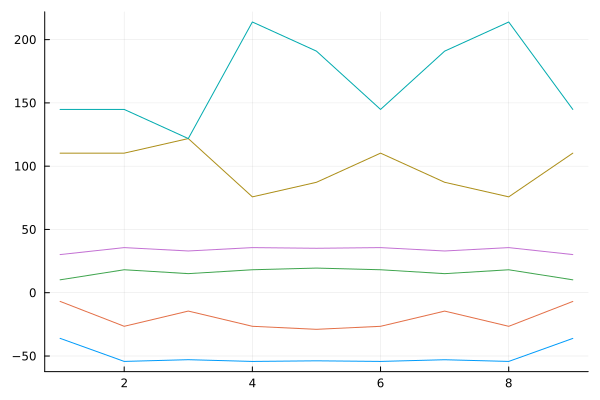

In [51]:
using Plots
ploteigenvalue=zeros(ComplexF64,9,111)
for ja in 1:9
 ploteigenvalue[ja,:]=pp["single_eigenvalue"][ja][1]
end

plot(collect(1:1:9),real.(ploteigenvalue[:,2*37-3:2*37+2]),legend=false)



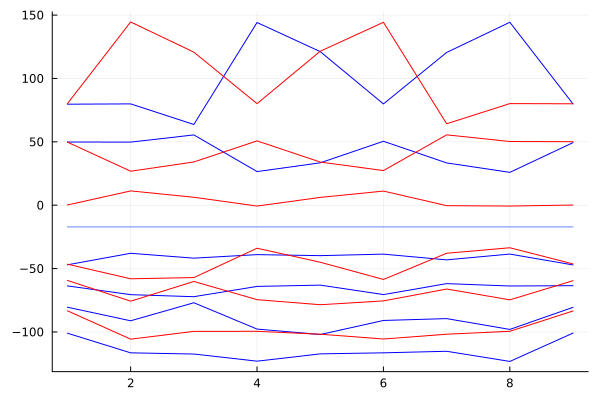

In [58]:
ploteigenvalue=zeros(ComplexF64,9,111)
for ja in 1:9
 ploteigenvalue[ja,:]=pp["HF_eigenvalue"][ja][1]
end
plot(collect(1:1:9),real.(ploteigenvalue[:,2*37-3:2*37+2]),legend=false,linecolor=:blue)

ploteigenvalue=zeros(ComplexF64,9,111)
for ja in 1:9
 ploteigenvalue[ja,:]=pp["HF_eigenvalue"][ja][2]
end
plot!(collect(1:1:9),real.(ploteigenvalue[:,2*37-3:2*37+2]),legend=false,linecolor=:red)
plot!([1,9],[pp["bound"],pp["bound"]])


In [53]:
index=2*37-1
l1=0
l2=0
l3=0
for ja in 1:37
   l1+=abs(pp["HF_eigenvector"][8][1][3*(ja-1)+1,index])^2
   l2+=abs(pp["HF_eigenvector"][8][1][3*(ja-1)+2,index])^2
   l3+=abs(pp["HF_eigenvector"][8][1][3*(ja-1)+3,index])^2
end

In [54]:
l1

0.30742259408087796

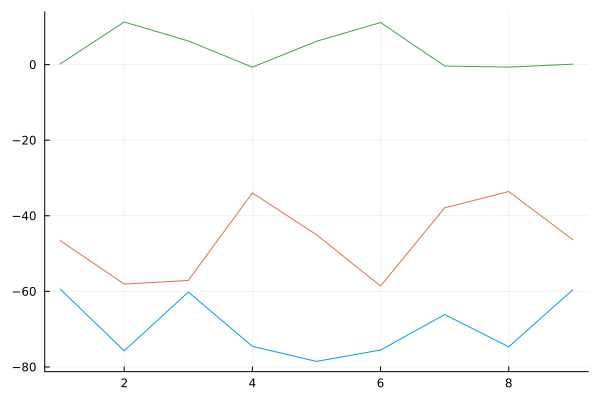

In [55]:
ploteigenvalue=zeros(ComplexF64,9,111)
for ja in 1:9
 ploteigenvalue[ja,:]=pp["HF_eigenvalue"][ja][2]
end
plot(collect(1:1:9),real.(ploteigenvalue[:,2*37-2:2*37]),legend=false)